# Breast Cancer Prediction using Machine Learning

This notebook demonstrates the process of building a machine learning model to predict breast cancer using the Wisconsin Diagnostic Breast Cancer Dataset. It covers data loading, preprocessing, model training, and evaluation.

Dataset loaded successfully.
         id diagnosis  mean radius  mean texture  mean perimeter  mean area  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   mean smoothness  mean compactness  mean concavity  mean concave points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  worst radius  worst textu

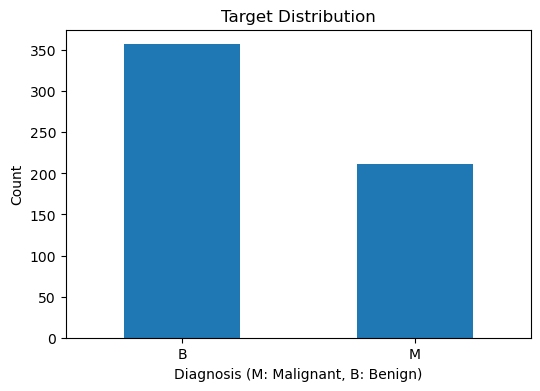

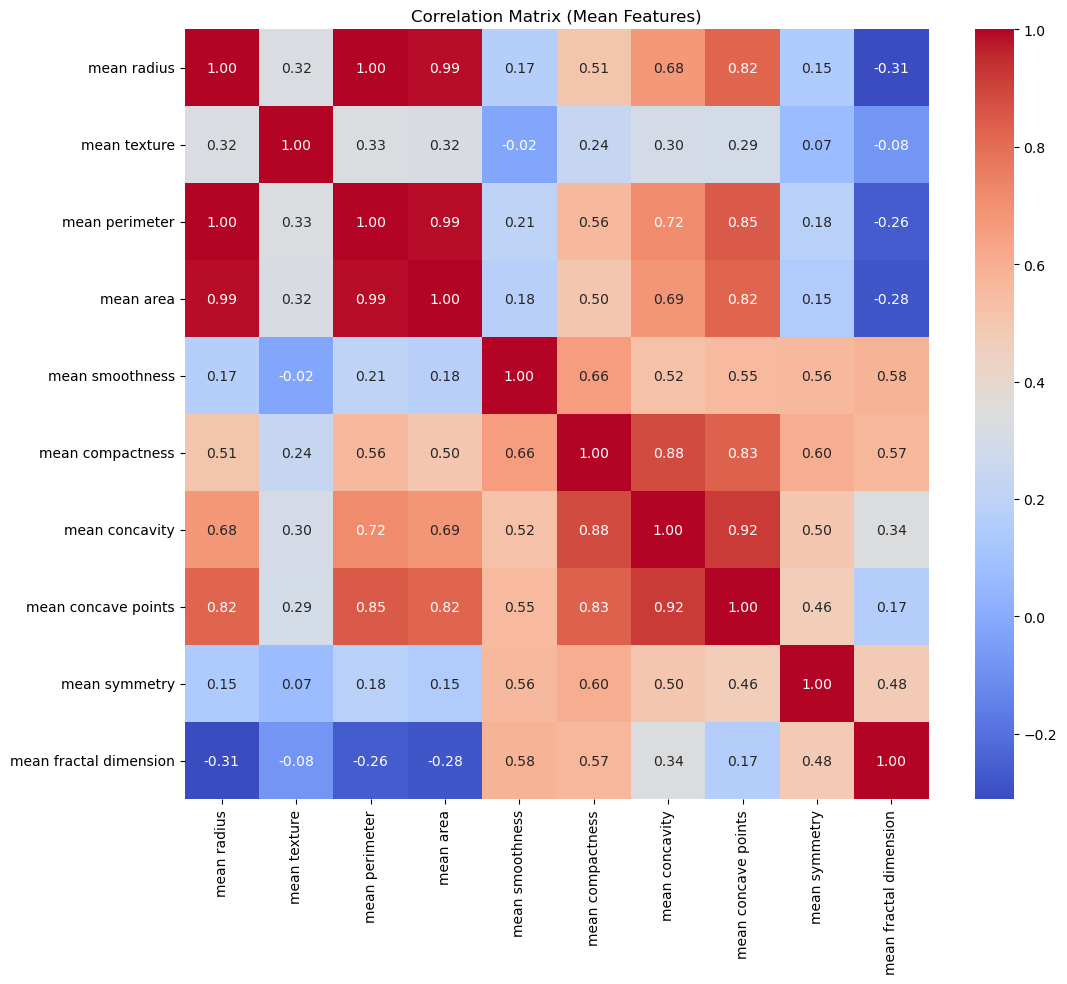

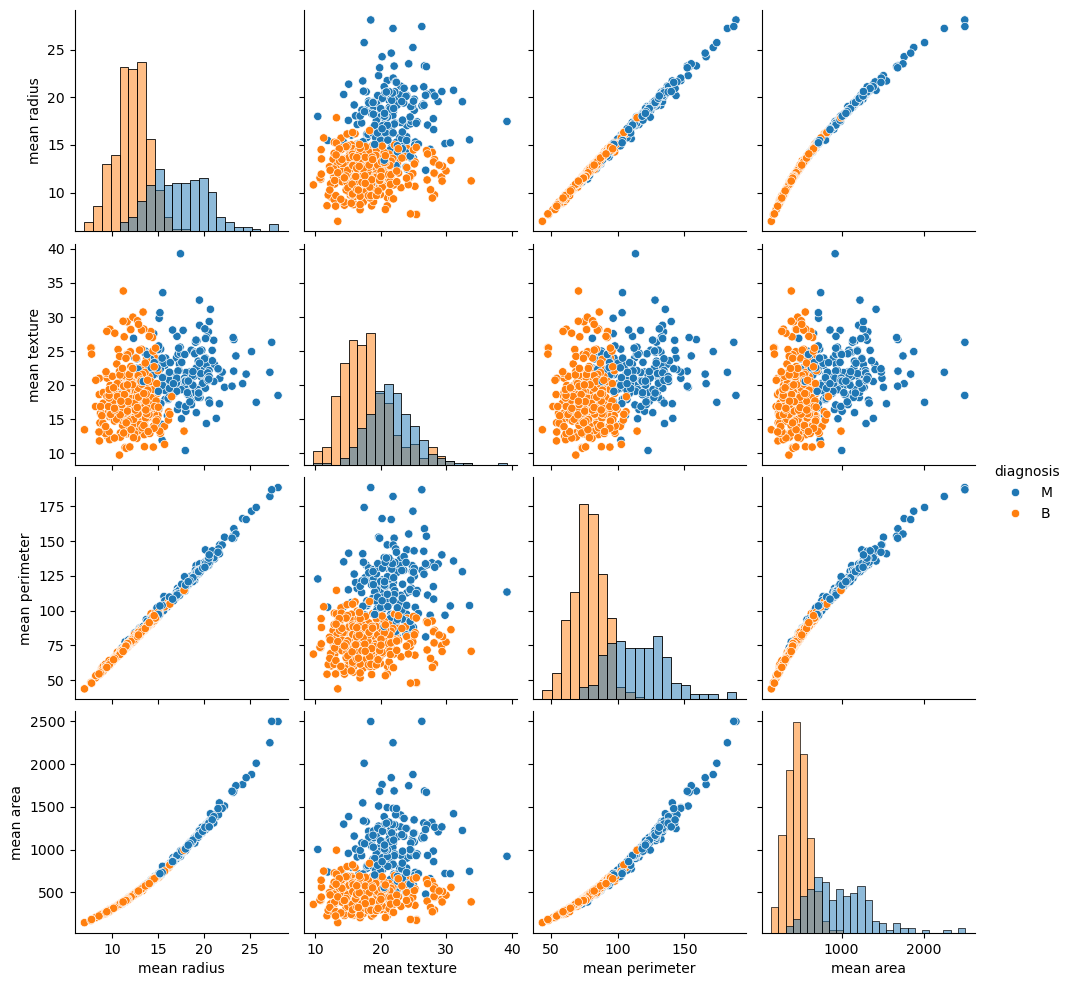

Starting tabular data preprocessing...
Tabular data preprocessing complete.

Shape of preprocessed features: (569, 30)
First 5 rows of preprocessed features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4         

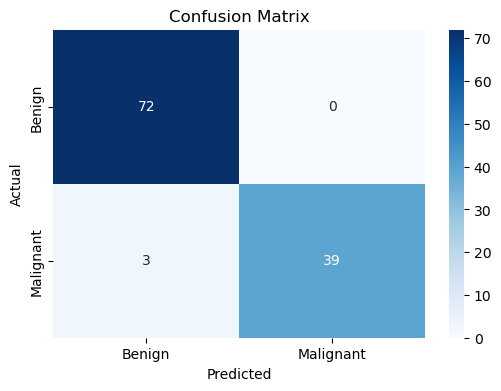

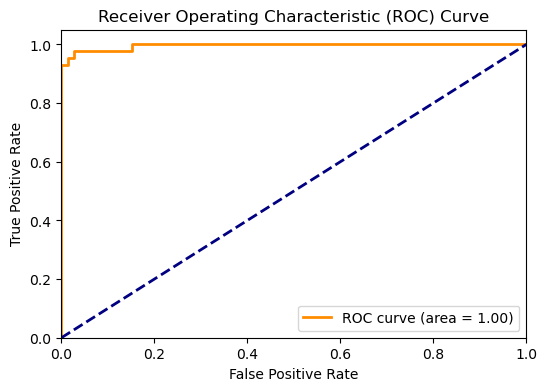

Model and preprocessor saved.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Import data_preprocessing utility
# Adjust this to point to your project's root directory
sys.path.append(os.path.abspath('../'))

from src.utils.data_preprocessing import preprocess_tabular_data

# --- 1. Data Loading ---
data_path = "../data/raw/breast_cancer/wdbc.data" # Adjust path as necessary

# Column names for the Wisconsin Diagnostic Breast Cancer dataset
column_names = [
    "id", "diagnosis",
    "mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness",
    "mean compactness", "mean concavity", "mean concave points", "mean symmetry", "mean fractal dimension",
    "radius error", "texture error", "perimeter error", "area error", "smoothness error",
    "compactness error", "concavity error", "concave points error", "symmetry error", "fractal dimension error",
    "worst radius", "worst texture", "worst perimeter", "worst area", "worst smoothness",
    "worst compactness", "worst concavity", "worst concave points", "worst symmetry", "worst fractal dimension"
]

try:
    data = pd.read_csv(data_path, names=column_names)
    print("Dataset loaded successfully.")
    print(data.head())
except FileNotFoundError:
    print(f"Error: {data_path} not found. Creating dummy data for demonstration.")
    # Create dummy data
    np.random.seed(42)
    data = pd.DataFrame({
        "id": range(1, 101),
        "diagnosis": np.random.choice(["M", "B"], 100),  # M: Malignant, B: Benign
        "mean radius": np.random.uniform(6, 28, 100),
        "mean texture": np.random.uniform(9, 40, 100),
        "mean perimeter": np.random.uniform(43, 189, 100),
        "mean area": np.random.uniform(143, 2501, 100),
        "mean smoothness": np.random.uniform(0.05, 0.16, 100),
        "mean compactness": np.random.uniform(0.02, 0.35, 100),
        "mean concavity": np.random.uniform(0, 0.43, 100),
        "mean concave points": np.random.uniform(0, 0.2, 100),
        "mean symmetry": np.random.uniform(0.1, 0.3, 100),
        "mean fractal dimension": np.random.uniform(0.05, 0.1, 100),
        "radius error": np.random.uniform(0.1, 3, 100),
        "texture error": np.random.uniform(0.4, 5, 100),
        "perimeter error": np.random.uniform(0.8, 22, 100),
        "area error": np.random.uniform(6, 542, 100),
        "smoothness error": np.random.uniform(0.002, 0.03, 100),
        "compactness error": np.random.uniform(0.002, 0.14, 100),
        "concavity error": np.random.uniform(0, 0.4, 100),
        "concave points error": np.random.uniform(0, 0.05, 100),
        "symmetry error": np.random.uniform(0.008, 0.08, 100),
        "fractal dimension error": np.random.uniform(0.001, 0.03, 100),
        "worst radius": np.random.uniform(7, 36, 100),
        "worst texture": np.random.uniform(12, 50, 100),
        "worst perimeter": np.random.uniform(50, 251, 100),
        "worst area": np.random.uniform(185, 4254, 100),
        "worst smoothness": np.random.uniform(0.07, 0.22, 100),
        "worst compactness": np.random.uniform(0.03, 1.06, 100),
        "worst concavity": np.random.uniform(0, 1.25, 100),
        "worst concave points": np.random.uniform(0, 0.29, 100),
        "worst symmetry": np.random.uniform(0.16, 0.66, 100),
        "worst fractal dimension": np.random.uniform(0.055, 0.21, 100)
    })

# --- 2. Exploratory Data Analysis (EDA) ---
print("\nDataset Info:")
data.info()

print("\nDataset Description:")
data.describe()

print("\nMissing values:")
print(data.isnull().sum())

# Target distribution
plt.figure(figsize=(6, 4))
data["diagnosis"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Diagnosis (M: Malignant, B: Benign)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Correlation matrix for mean features
mean_features = [col for col in data.columns if "mean" in col]
plt.figure(figsize=(12, 10))
sns.heatmap(data[mean_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Mean Features)")
plt.show()

# Pairplot for selected mean features
selected_features = ["mean radius", "mean texture", "mean perimeter", "mean area", "diagnosis"]
sns.pairplot(data[selected_features], hue="diagnosis", diag_kind="hist")
plt.show()

# --- 3. Data Preprocessing ---
# Drop ID column as it"s not useful for prediction
data = data.drop(columns=["id"])

# Define columns for preprocessing
numerical_cols = [
    "mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness",
    "mean compactness", "mean concavity", "mean concave points", "mean symmetry", "mean fractal dimension",
    "radius error", "texture error", "perimeter error", "area error", "smoothness error",
    "compactness error", "concavity error", "concave points error", "symmetry error", "fractal dimension error",
    "worst radius", "worst texture", "worst perimeter", "worst area", "worst smoothness",
    "worst compactness", "worst concavity", "worst concave points", "worst symmetry", "worst fractal dimension"
]
categorical_cols = []  # All features are numerical
target_column = "diagnosis"

# Convert target to binary (0: Benign, 1: Malignant)
data[target_column] = data[target_column].map({"B": 0, "M": 1})

X_processed, y, preprocessor = preprocess_tabular_data(data, numerical_cols, categorical_cols, target_column)

print("\nShape of preprocessed features:", X_processed.shape)
print("First 5 rows of preprocessed features:")
print(X_processed.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# --- 4. Model Building (Support Vector Machine) ---
model = SVC(probability=True, random_state=42, kernel="rbf")

print("Training Support Vector Machine model...")
model.fit(X_train, y_train)
print("Model training complete.")

# --- 5. Model Evaluation ---
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

# --- 6. Save Model (Optional) ---
import joblib
joblib.dump(model, "breast_cancer_svm_model.pkl")
joblib.dump(preprocessor, "breast_cancer_preprocessor.pkl")
print("Model and preprocessor saved.")
